# Aprendizaje de Máquina - Laboratorio 3

## Integrantes

| Nombre             | Código    | Correo electrónico           |
|--------------------|-----------|------------------------------|
| Adrian Velasquez   | 202222737 | a.velasquezs@uniandes.edu.co |
| Andres Botero Ruiz | 202223503 | a.boteror@uniandes.edu.co    |

# Preparación del entorno de trabajo y carga de datos

In [214]:
# Definición de constantes

DATA_PATH = './data/'
DATA_FILE = DATA_PATH + 'data.csv'
TEST_FILE = DATA_PATH + 'test.csv'

In [215]:
# Importar librerias

import re
import unicodedata

# Data + graphics
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Scikit-learn
from sklearn import set_config
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, classification_report, confusion_matrix, \
    ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, FunctionTransformer, StandardScaler, MinMaxScaler, OneHotEncoder, \
    RobustScaler, Normalizer, MaxAbsScaler
from sklearn.utils import resample
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import StratifiedKFold


In [216]:
# Cargar los datos
data = pd.read_csv(DATA_FILE, encoding='iso-8859-1', delimiter=';')
df = data.copy()
df.head()

,Edad,Gnereo,Peso,Altura,BMI,Objetivo,Condicion_salud,Nivel_Actividad,Nivel_experiencia,Dieta_preferida,...,Fumador,Cigarrillos_dia,Alcohol,Alcohol_semana,Score_micronutrientes,Ingesta_proteinas,Pasos_dia,Ingesta_agua,Plan_entrenamiento,Plan_nutrición
0,60,Masculino,73.7,1.61,28.43,Resistencia,Hipertension,Bajo,Avanzado,Vegano,...,0,0.0,0,0.0,0.92,182.1,16485,2.49,Medio,Sin plan
1,17,Femenino,121.0,1.97,31.18,Resistencia,Enfermedad corazon,Moderado,Principiante,Vegetariano,...,0,0.0,0,0.0,0.76,167.7,14256,2.04,Ninguno,Sin plan
2,43,Masculino,110.0,1.52,47.61,General,Ninguno,Bajo,Principiante,No-Vegetariano,...,0,0.0,0,0.0,0.34,104.9,3050,2.53,Bajo,Basico
3,49,Otro,73.6,1.96,19.16,General,Ninguno,Moderado,Principiante,No-Vegetariano,...,0,0.0,0,0.0,0.71,59.5,2264,3.36,Ninguno,Sin plan
4,53,Femenino,80.8,1.76,26.08,Resistencia,Hipertension,Alto,Principiante,Pescetariano,...,1,8.7,0,0.0,0.98,51.1,12774,1.90,Medio,Sin plan


In [217]:
# Crear un FunctionTransformer para limpiar nombres de las columnas (añadir al pipeline)
def clean_column_names(t_df):
    t_df = t_df.copy()
    if 'Gnereo' in t_df.columns:
        t_df['Genero'] = t_df['Gnereo']  # Corregir el typo
        t_df = t_df.drop(columns=['Gnereo'])
    new_cols = []
    for col in t_df.columns:
        col = str(col)
        # quitar tildes/acentos
        col = unicodedata.normalize("NFKD", col).encode("ascii", "ignore").decode("ascii")
        # normalizar formato
        col = col.strip().lower()
        col = re.sub(r"\s+", "_", col)  # espacios -> _
        col = re.sub(r"[^a-z0-9_]", "", col)  # borrar caracteres raros
        new_cols.append(col)

    t_df.columns = new_cols
    return t_df


ft_name_cleaner = FunctionTransformer(clean_column_names, validate=False)

In [218]:
# Limpiar nombres de las columnas
df = ft_name_cleaner.transform(df)
df.sample(5)

,edad,peso,altura,bmi,objetivo,condicion_salud,nivel_actividad,nivel_experiencia,dieta_preferida,horas_sueno,...,cigarrillos_dia,alcohol,alcohol_semana,score_micronutrientes,ingesta_proteinas,pasos_dia,ingesta_agua,plan_entrenamiento,plan_nutricion,genero
7429,61,103.6,2.03,25.14,Ganancia muscular,Hipertension,Alto,Intermedio,Vegetariano,5.7,...,0.0,1,7.7,0.99,184.1,16989,2.21,Medio,Balanceado,Femenino
2583,68,112.2,1.62,42.75,Ganancia muscular,Ninguno,Bajo,Avanzado,Pescetariano,6.1,...,2.9,0,0.0,0.75,61.7,15249,2.53,Medio,Balanceado,Femenino
7341,39,131.4,1.72,44.42,General,Ninguno,Moderado,Intermedio,Vegetariano,7.7,...,0.0,0,0.0,0.34,173.0,17638,3.87,Ninguno,Basico,Femenino
1125,38,104.8,1.66,38.03,Resistencia,Hipertension,Moderado,Avanzado,No-Vegetariano,5.4,...,0.0,0,0.0,0.80,209.1,14692,2.19,Medio,Sin plan,Masculino
4289,30,76.7,1.96,19.97,Perdida grasa,Ninguno,Moderado,Principiante,Pescetariano,6.1,...,0.0,1,9.3,0.31,167.6,16043,2.40,Ninguno,Balanceado,Femenino


In [219]:
# Definición de las variables objetivo (son 2 de acuerdo al negocio)
VOE = 'plan_entrenamiento'
VON = 'plan_nutricion'

In [220]:
# Separación de variables numéricas y categóricas
numerical_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object', 'string']).columns

# Análisis exploratorio y calidad de datos

In [221]:
# Información general del dataset
print(f"Cantidad de filas: {len(df)}")
print(f"Cantidad de columnas: {len(df.columns)}")
print("\nTipos de datos:")
df.info()

Cantidad de filas: 9698
Cantidad de columnas: 26

Tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9698 entries, 0 to 9697
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   edad                     9698 non-null   int64  
 1   peso                     9687 non-null   float64
 2   altura                   9698 non-null   float64
 3   bmi                      9698 non-null   float64
 4   objetivo                 9698 non-null   object 
 5   condicion_salud          9698 non-null   object 
 6   nivel_actividad          9698 non-null   object 
 7   nivel_experiencia        9698 non-null   object 
 8   dieta_preferida          9698 non-null   object 
 9   horas_sueno              9698 non-null   float64
 10  entrenamiento_preferido  9698 non-null   object 
 11  cantidad_equipo          9698 non-null   int64  
 12  tiempo_disponible        9698 non-null   int64  
 13  tiene_alergi

Solo hay 1 nulo en la columna de peso, de resto hay completitud en los datos

In [222]:
# Descripción de variables numéricas
df.describe()

,edad,peso,altura,bmi,horas_sueno,cantidad_equipo,tiempo_disponible,tiene_alergia,problemas_digestivos,fumador,cigarrillos_dia,alcohol,alcohol_semana,score_micronutrientes,ingesta_proteinas,pasos_dia,ingesta_agua
count,9698.000000,9687.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000
mean,45.112601,92.622515,1.775047,30.131391,7.004382,2.988039,67.194061,0.201588,0.153846,0.227366,2.172252,0.285317,3.778841,0.500115,129.997360,9765.936482,2.748532
std,17.641045,27.383913,0.158754,10.605675,1.449454,2.018493,30.839475,0.401207,0.360820,0.419153,4.624756,0.451588,7.023263,0.289062,51.981874,4762.152079,1.015342
min,15.000000,45.000000,1.500000,10.930000,0.000000,0.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,40.000000,200.000000,1.000000
25%,30.000000,68.800000,1.640000,21.620000,5.800000,1.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.250000,85.000000,5608.250000,1.860000
50%,45.000000,92.600000,1.780000,29.190000,7.000000,3.000000,67.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,129.950000,9718.000000,2.760000
75%,61.000000,116.500000,1.910000,37.060000,8.200000,5.000000,94.000000,0.000000,0.000000,0.000000,0.000000,1.000000,4.300000,0.750000,175.200000,13953.000000,3.620000
max,75.000000,140.000000,2.050000,62.090000,23.000000,6.000000,120.000000,1.000000,1.000000,1.000000,18.000000,1.000000,25.000000,1.000000,220.000000,17996.000000,4.500000


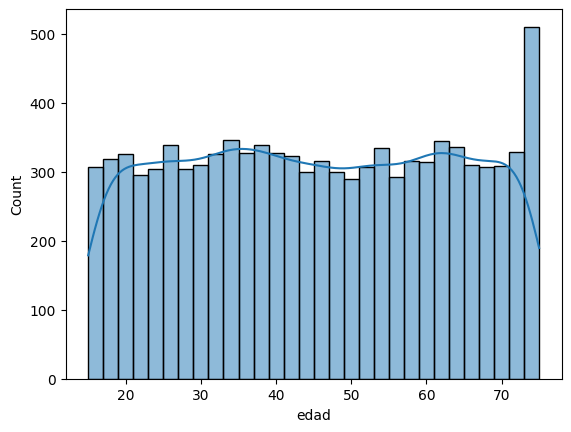

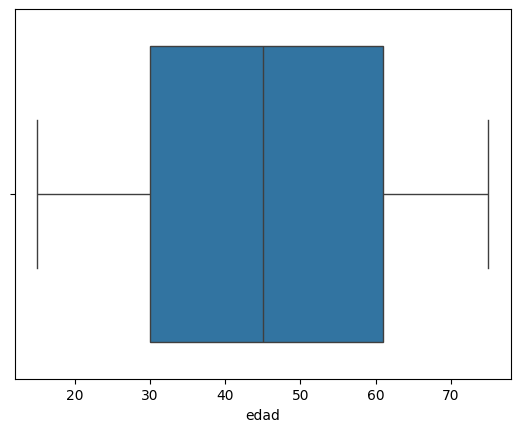

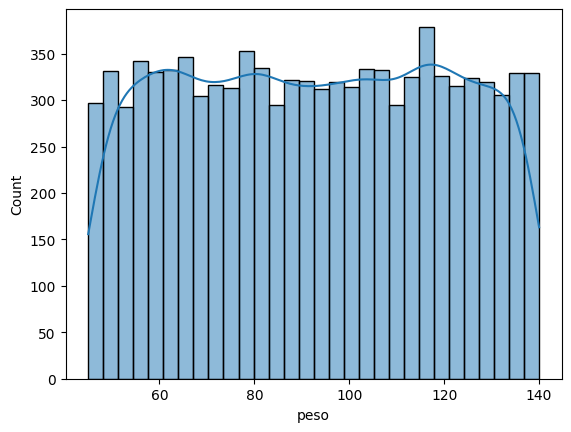

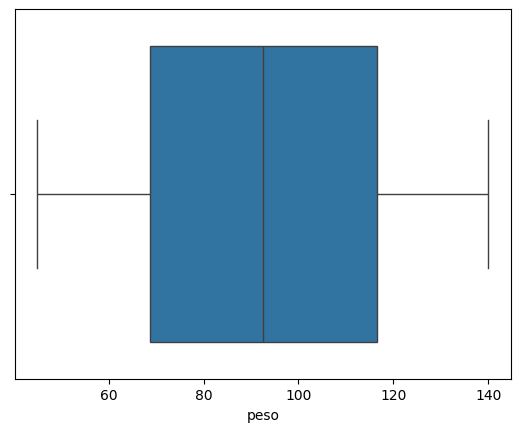

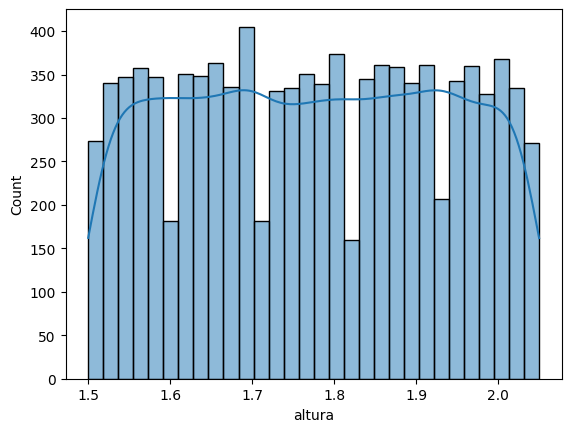

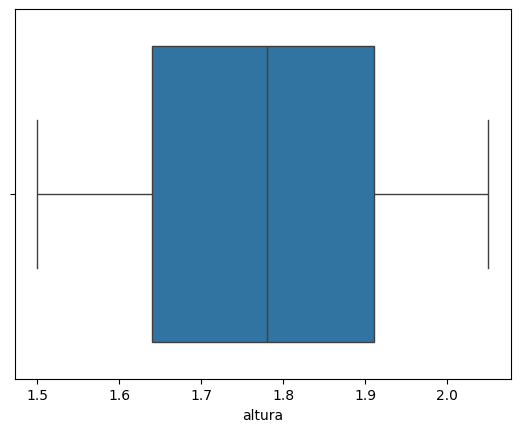

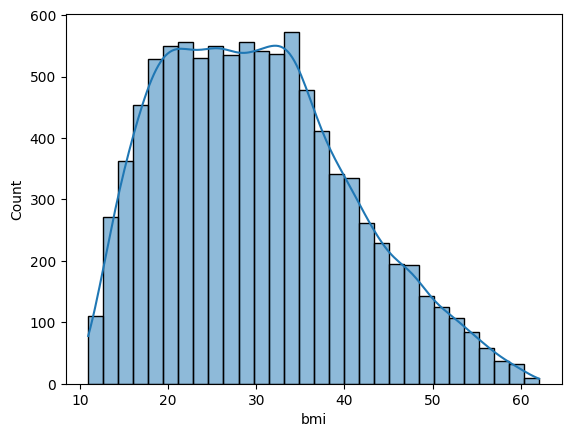

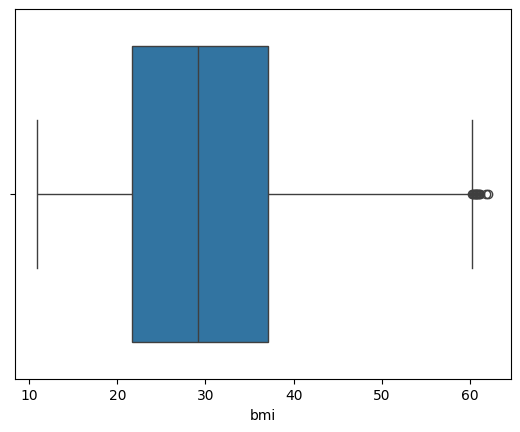

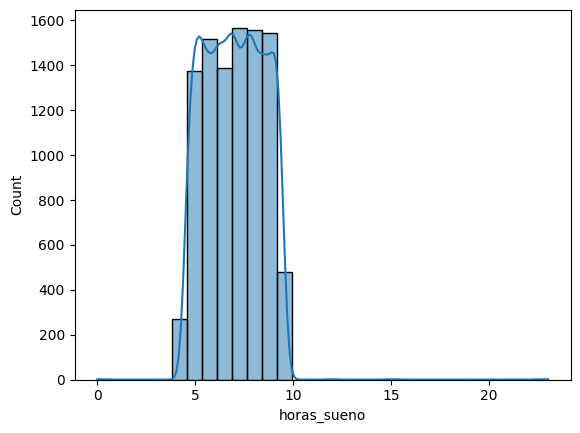

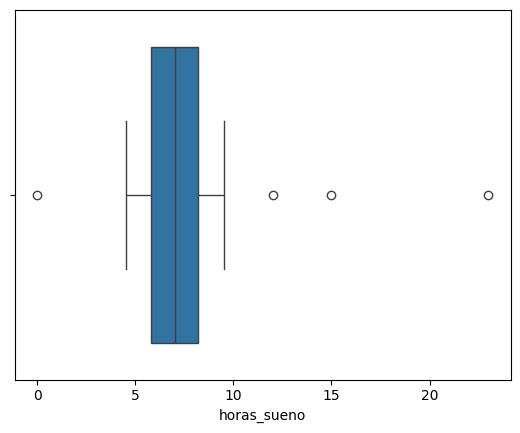

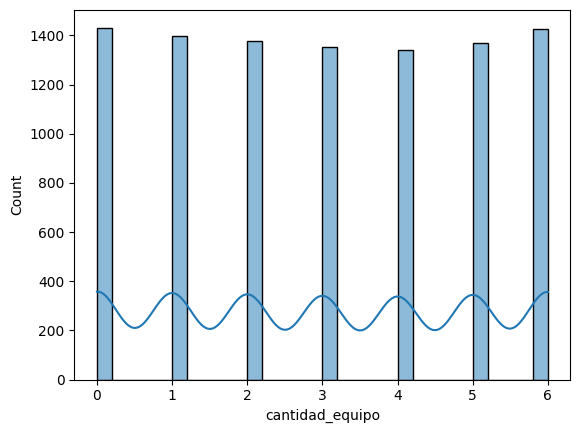

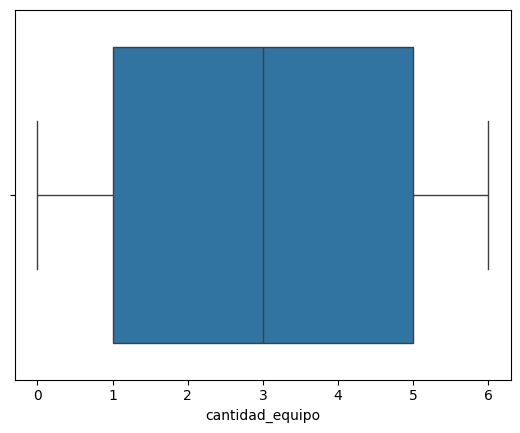

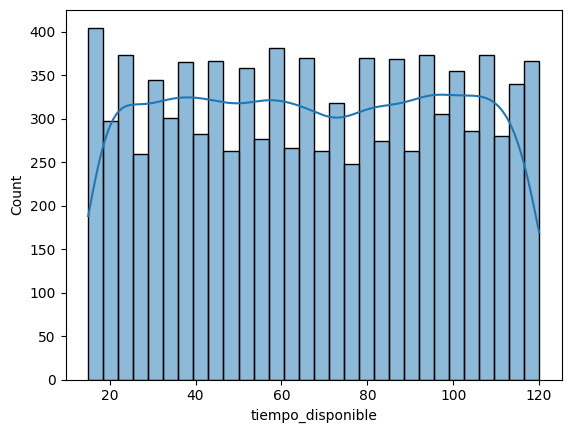

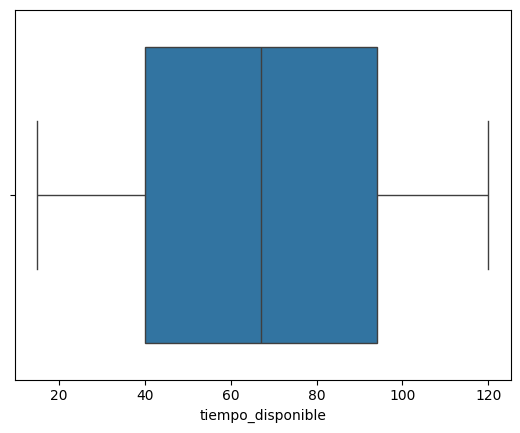

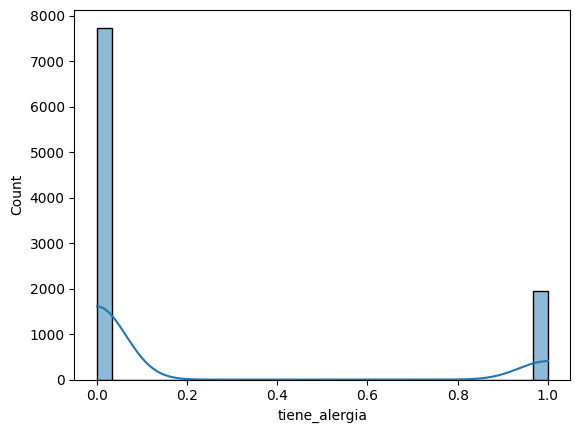

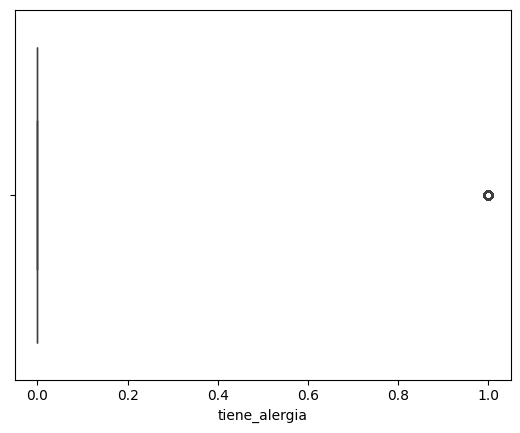

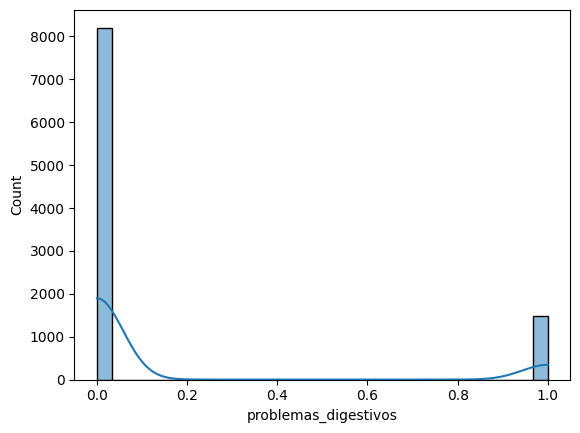

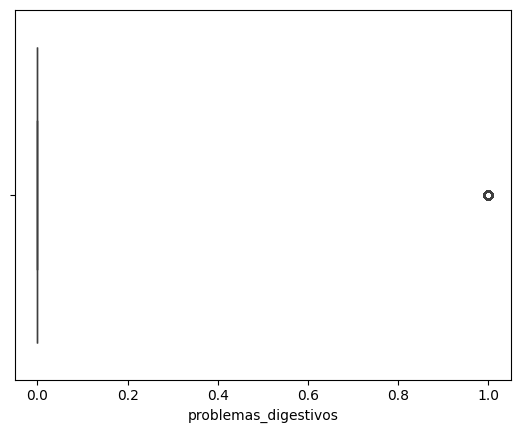

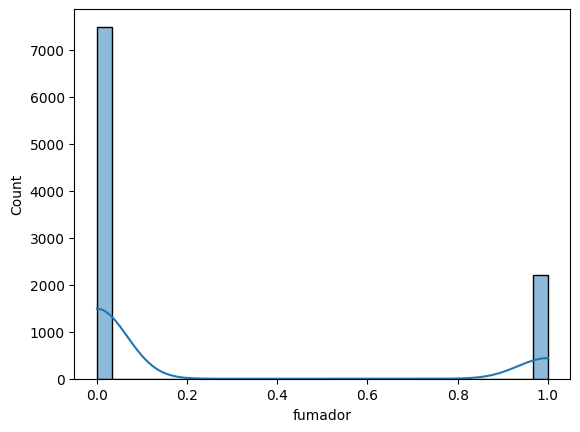

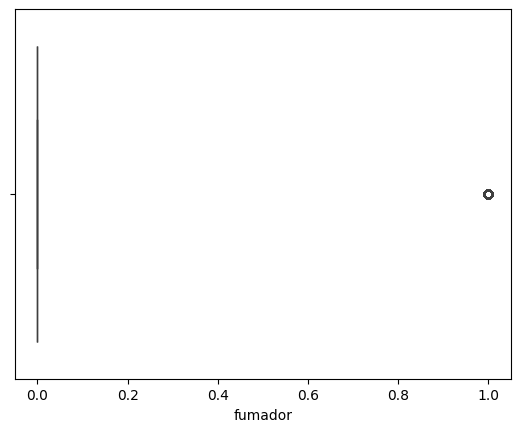

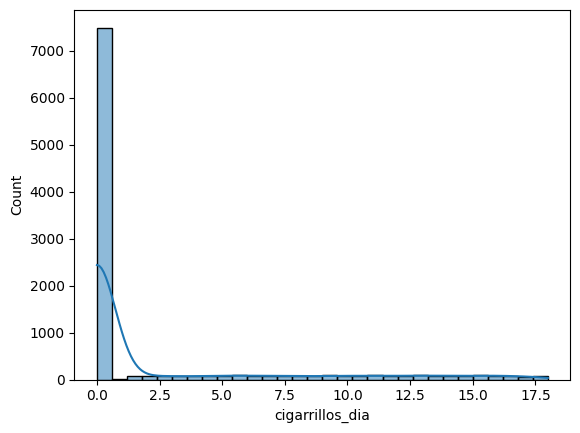

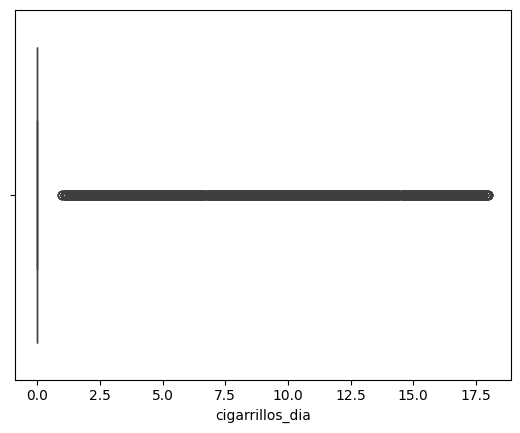

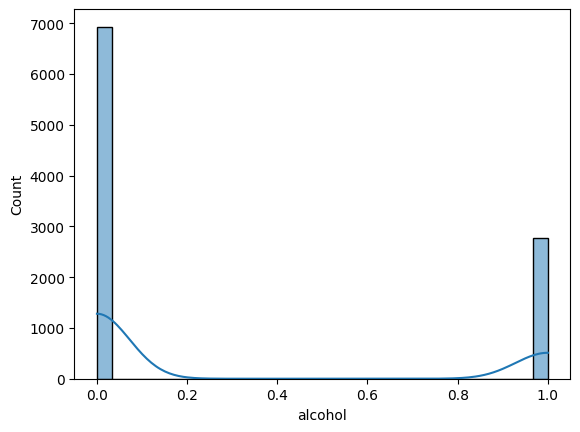

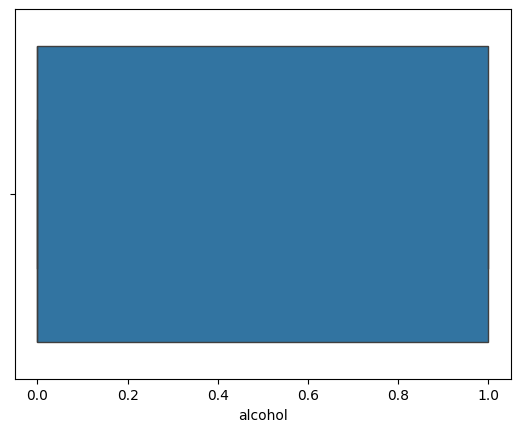

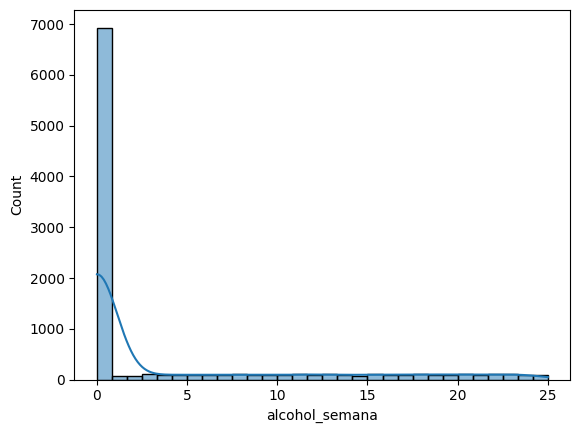

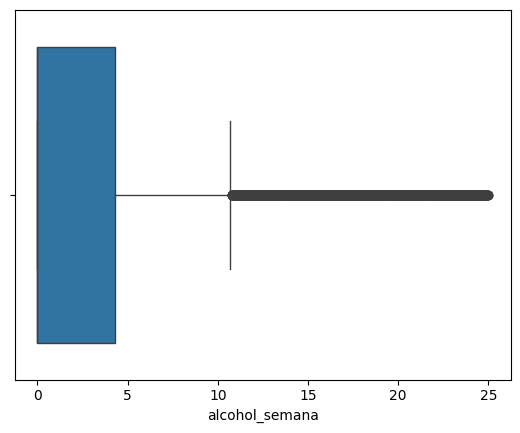

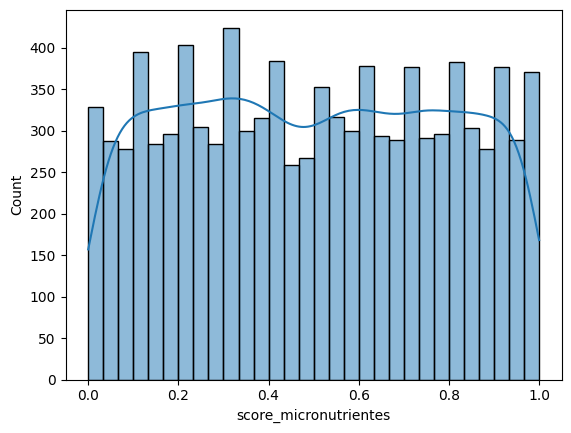

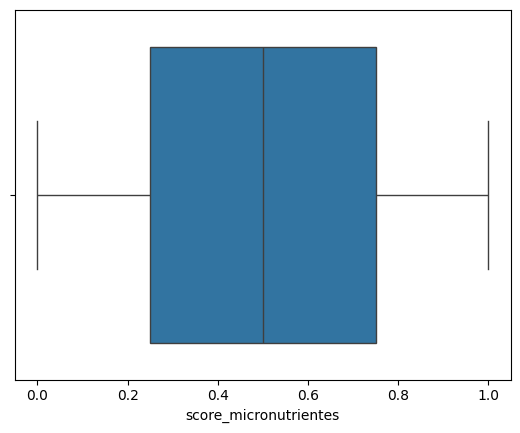

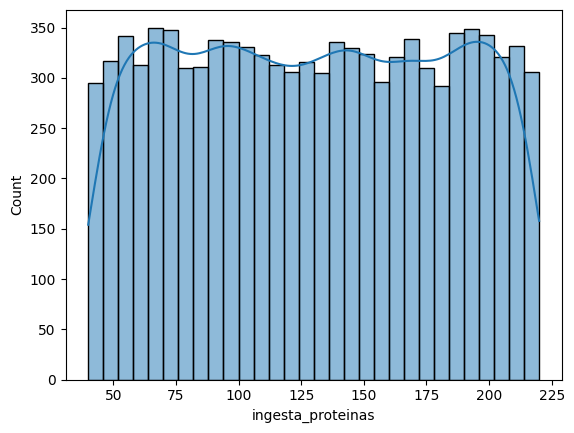

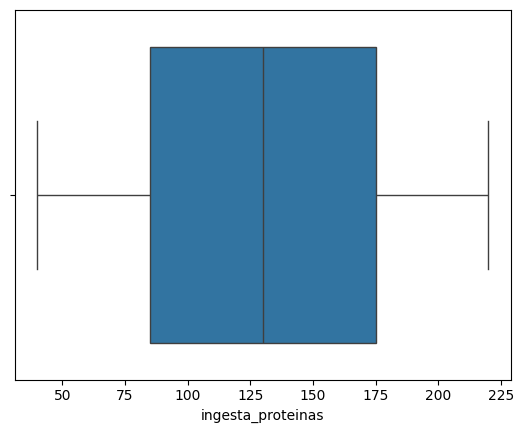

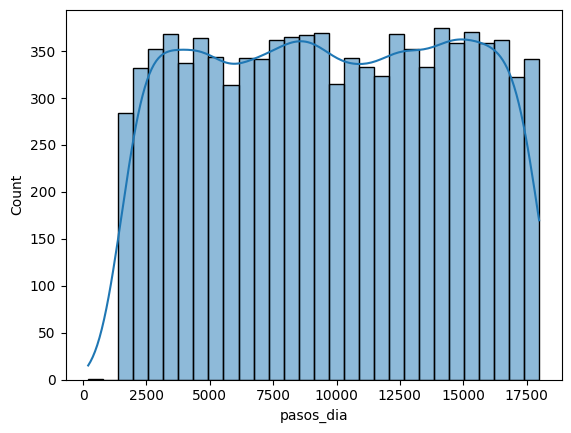

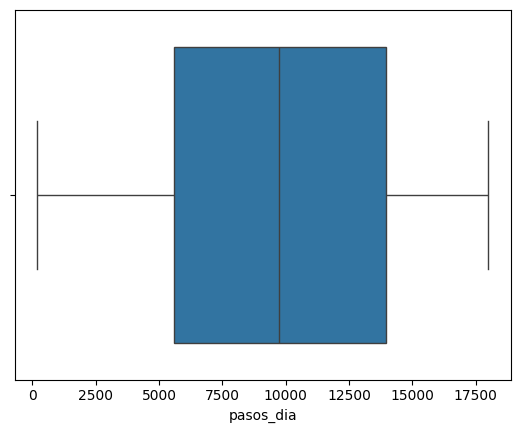

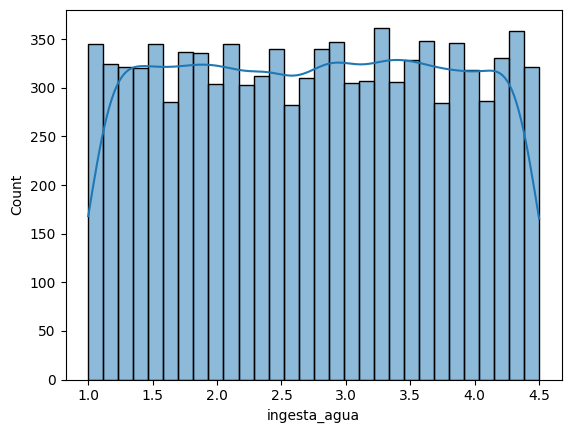

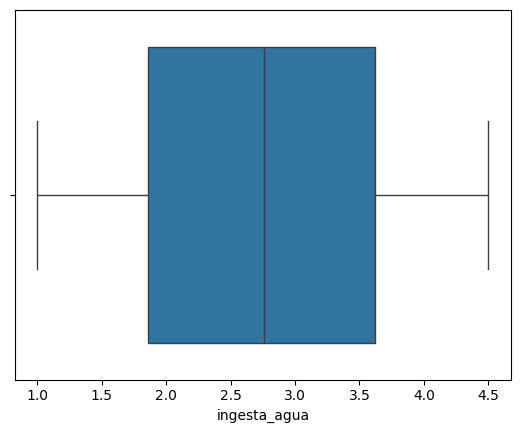

In [223]:
# Gráficas de variables numéricas
for c in numerical_cols:
    sns.histplot(data=df, x=c, kde=True, bins=30)
    plt.show()
    # plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[c])
    plt.show()

En general los datos parecen estar en rangos razonables. Algunas excepciones son:

1. `horas_sueño`: hay al menos un valor de 0 horas de sueño, y al menos un valor de 23 horas de sueño, ambos extremos son poco probables. Esto podría ser un error de registro o casos extremos que podrían considerarse outliers.
2. `tiene_alergia`, `problemas_digestivos`, `fumador`, `alcohol`: Parecen ser variables binarias. Pueden ser consideradas como categóricas, aunque están representadas como numéricas. Se podría considerar convertirlas a variables categóricas para un análisis más adecuado.
3. Con `peso` y `altura` se puede verificar si el `bmi` es consistente, ya que se calcula como $BMI = \frac{peso\ \left(kg\right)}{\left(altura\ \left(m\right)\right)^2}$\. Si hay inconsistencias, podrían ser errores de registro o casos extremos que podrían considerarse outliers\.


Columna: objetivo
objetivo
Ganancia muscular    2757
Perdida grasa        2594
General              2220
Resistencia          2123
grasa                   4
Name: count, dtype: int64


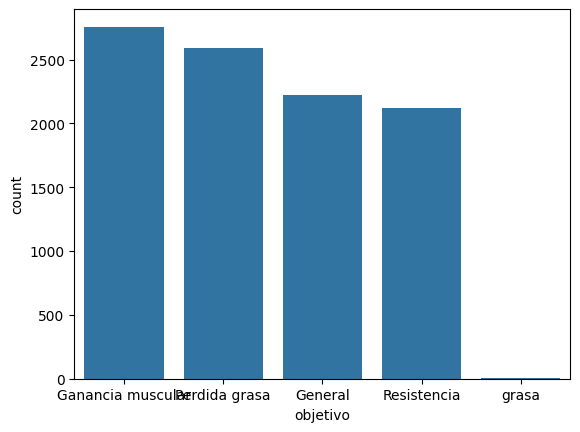


Columna: condicion_salud
condicion_salud
Ninguno               6030
Hipertension           814
Lesion                 764
Asma                   745
Diabetes               511
Enfermedad corazon     497
PCOS                   337
Name: count, dtype: int64


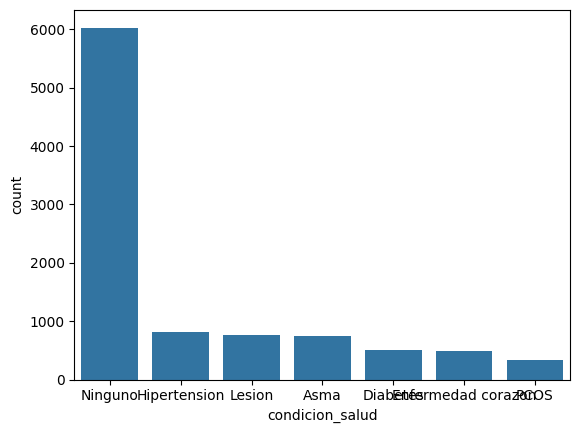


Columna: nivel_actividad
nivel_actividad
Moderado    3594
Bajo        3326
Alto        2778
Name: count, dtype: int64


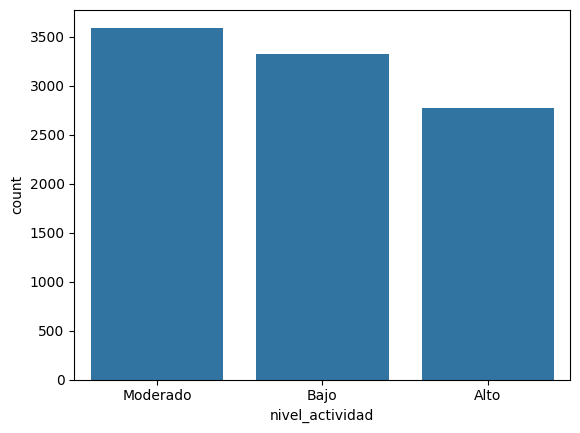


Columna: nivel_experiencia
nivel_experiencia
Intermedio      4100
Principiante    3608
Avanzado        1990
Name: count, dtype: int64


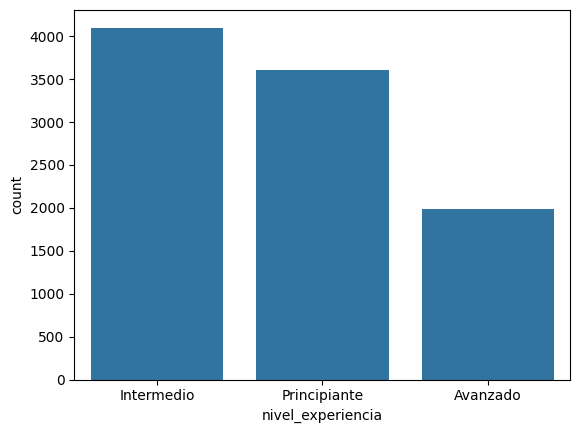


Columna: dieta_preferida
dieta_preferida
No-Vegetariano    2456
Vegano            2426
Pescetariano      2403
Vegetariano       2402
Animal              11
Name: count, dtype: int64


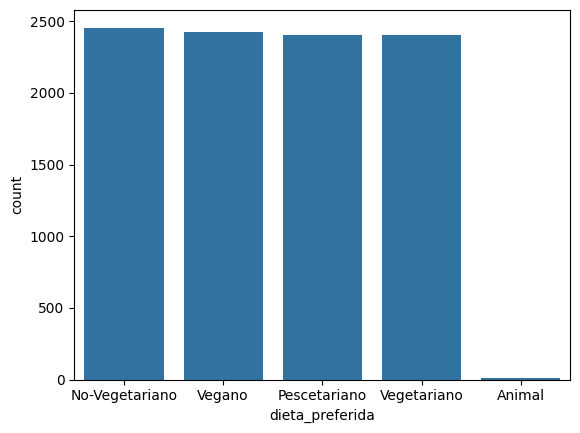


Columna: entrenamiento_preferido
entrenamiento_preferido
Funcional       1666
Hit             1620
Flexibilidad    1618
Cardio          1602
Fuerza          1601
Balance         1591
Name: count, dtype: int64


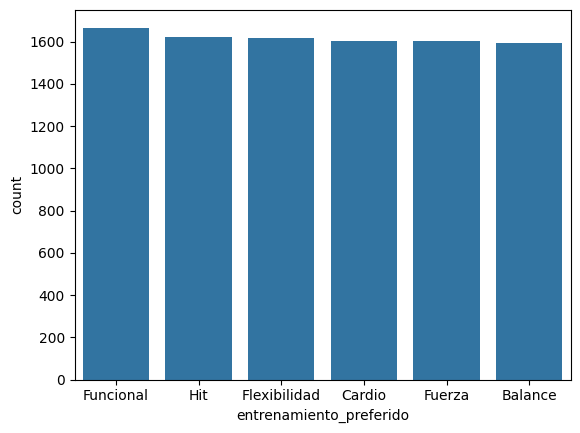


Columna: plan_entrenamiento
plan_entrenamiento
Ninguno    3807
Medio      2945
Bajo       2290
Alto        656
Name: count, dtype: int64


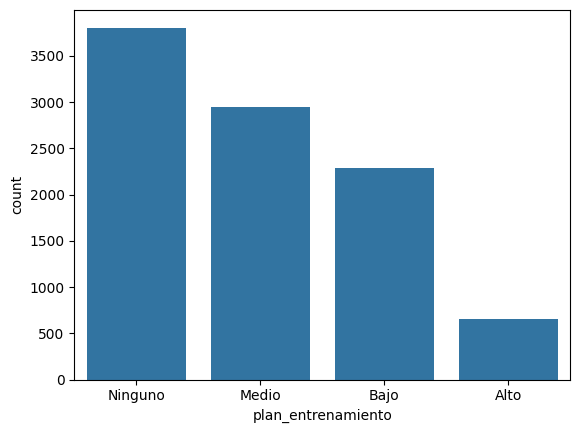


Columna: plan_nutricion
plan_nutricion
Balanceado       4297
Sin plan         2522
Basico           2287
Especializado     592
Name: count, dtype: int64


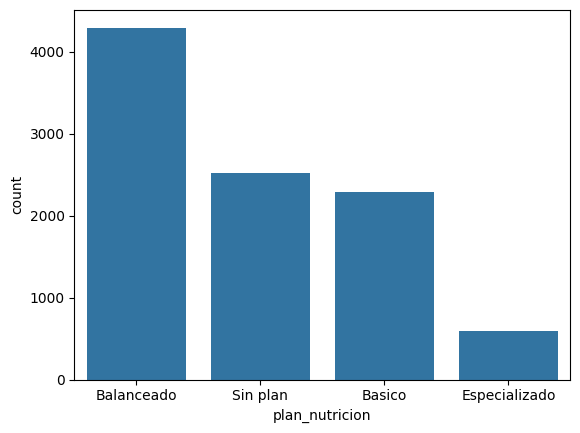


Columna: genero
genero
Femenino     4719
Masculino    4611
Otro          368
Name: count, dtype: int64


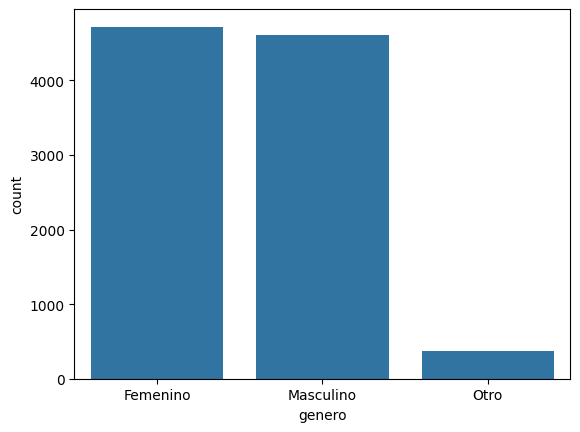

In [224]:
# Descripción de variables categóricas
for c in categorical_cols:
    print(f"\nColumna: {c}")
    print(df[c].value_counts())
    sns.countplot(data=df, x=c, order=df[c].value_counts().index)
    plt.show()

Todos los valores de las variables categóricas son sensatos, exceptuando 2 escenarios.

1. `objetivo`: hay 4 valores de "grasa". Esto se puede atribuir a un error de tipeo, se puede corregir a "Perdida grasa" para mantener la consistencia con los otros valores de esa columna.
2. `dieta_preferida`: hay tan solo 11 valores de "Animal". Estos podrían potencialmente ser considerados outliers, a pesar de ser válidos. Se podría considerar eliminar estos registros para evitar que afecten el análisis posterior, aunque también se podría mantener esta información si se considera relevante para el estudio.

# Limpieza de datos

In [225]:
# Copiar el df para la limpieza
clean_df = df.copy()
clean_df.shape

(9698, 26)

### Horas de sueño

In [226]:
# Verificar horas de sueño

print(f"Cantidad de registros con 0 horas de sueño: {len(clean_df[clean_df['horas_sueno'] == 0])}")

print(f"Cantidad de registros con 23 horas de sueño: {len(clean_df[clean_df['horas_sueno'] == 23])}")

print(f"Cantidad de registros con menos de 4 horas de sueño: {len(clean_df[clean_df['horas_sueno'] <= 4])}")

print(f"Cantidad de registros con más de 14 horas de sueño: {len(clean_df[clean_df['horas_sueno'] >= 14])}")

# Eliminar registros con 0 horas de sueño
clean_df = clean_df[clean_df['horas_sueno'] != 0]
clean_df = clean_df[clean_df['horas_sueno'] != 23]

print(f"Cantidad de registros después de eliminar casos extremos en horas de sueño: {len(clean_df)}")

Cantidad de registros con 0 horas de sueño: 1
Cantidad de registros con 23 horas de sueño: 1
Cantidad de registros con menos de 4 horas de sueño: 1
Cantidad de registros con más de 14 horas de sueño: 2
Cantidad de registros después de eliminar casos extremos en horas de sueño: 9696


In [227]:
# Verificar resultados
clean_df['horas_sueno'].describe()

count    9696.000000
mean        7.003455
std         1.438714
min         4.500000
25%         5.800000
50%         7.000000
75%         8.200000
max        15.000000
Name: horas_sueno, dtype: float64

En general, los nuevos datos parecen tener valores coherentes. Hay una persona con 15 horas de sueño, lo cual es alto pero no del todo imposible, por lo que se decidió mantener este registro. Sin embargo, se eliminaron los registros con 0 horas de sueño y 23 horas de sueño, ya que estos valores son poco probables y podrían ser errores de registro o casos extremos que podrían afectar el análisis posterior.

### Variables binarias representadas como numéricas

In [228]:
# Convertir variables binarias a categóricas

def transform_binary(t_df: pd.DataFrame) -> pd.DataFrame:
    t_df = t_df.copy()
    binary_cols = ['tiene_alergia', 'problemas_digestivos', 'fumador', 'alcohol']
    
    mapping = {0: 'No', 1: 'Si', 'No': 'No', 'Si': 'Si'}
    
    for c in binary_cols:
        t_df[c] = t_df[c].map(mapping)
        
    return t_df


ft_binary_cleaner = FunctionTransformer(transform_binary, validate=False)

In [229]:
# Aplicar la transformación
clean_df = ft_binary_cleaner.transform(clean_df)
clean_df.head()

,edad,peso,altura,bmi,objetivo,condicion_salud,nivel_actividad,nivel_experiencia,dieta_preferida,horas_sueno,...,cigarrillos_dia,alcohol,alcohol_semana,score_micronutrientes,ingesta_proteinas,pasos_dia,ingesta_agua,plan_entrenamiento,plan_nutricion,genero
0,60,73.7,1.61,28.43,Resistencia,Hipertension,Bajo,Avanzado,Vegano,5.5,...,0.0,No,0.0,0.92,182.1,16485,2.49,Medio,Sin plan,Masculino
1,17,121.0,1.97,31.18,Resistencia,Enfermedad corazon,Moderado,Principiante,Vegetariano,6.9,...,0.0,No,0.0,0.76,167.7,14256,2.04,Ninguno,Sin plan,Femenino
2,43,110.0,1.52,47.61,General,Ninguno,Bajo,Principiante,No-Vegetariano,6.0,...,0.0,No,0.0,0.34,104.9,3050,2.53,Bajo,Basico,Masculino
3,49,73.6,1.96,19.16,General,Ninguno,Moderado,Principiante,No-Vegetariano,5.7,...,0.0,No,0.0,0.71,59.5,2264,3.36,Ninguno,Sin plan,Otro
4,53,80.8,1.76,26.08,Resistencia,Hipertension,Alto,Principiante,Pescetariano,5.8,...,8.7,No,0.0,0.98,51.1,12774,1.90,Medio,Sin plan,Femenino


### Verificar BMI

In [230]:
# Verificar consistencia de BMI

def calc_bmi(weight_series: pd.Series, height_series: pd.Series) -> pd.Series:
    bmi = weight_series / (height_series ** 2)
    return bmi


t_df = clean_df.copy()
calculated_bmi = round(calc_bmi(t_df['peso'], t_df['altura']), 2)
bmi_diff = np.abs(calculated_bmi - t_df['bmi'])
inconsistent_bmi = t_df[bmi_diff > 1]  # Considerar inconsistencias mayores a 1 punto de BMI
print(f"Cantidad de registros con BMI inconsistente: {len(inconsistent_bmi)}")

Cantidad de registros con BMI inconsistente: 0


No se encontraron inconsistencias significativas en el BMI

### Consistencia en Objetivo

In [231]:
# Corregir typo en objetivo
t_df = clean_df.copy()

t_df['objetivo'] = t_df['objetivo'].map({'grasa': 'Perdida grasa',
                                         'Perdida grasa': 'Perdida grasa',
                                         'Ganancia muscular': 'Ganancia muscular',
                                         'General': 'General',
                                         'Resistencia': 'Resistencia', })

t_df['objetivo'].describe()

count                  9696
unique                    4
top       Ganancia muscular
freq                   2755
Name: objetivo, dtype: object

In [232]:
t_df['objetivo'].value_counts()

objetivo
Ganancia muscular    2755
Perdida grasa        2598
General              2220
Resistencia          2123
Name: count, dtype: int64

In [233]:
# Conviene generalizarlo para el pipeline

def objetivo_consistency(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    objetivo_map = {
        'grasa': 'Perdida grasa',
        'Perdida grasa': 'Perdida grasa',
        'Ganancia muscular': 'Ganancia muscular',
        'General': 'General',
        'Resistencia': 'Resistencia',
    }

    if 'objetivo' in df.columns:
        df['objetivo'] = df['objetivo'].map(objetivo_map)

    return df

ft_objetivo_consistency = FunctionTransformer(objetivo_consistency)

In [234]:
clean_df = t_df.copy()

### Dieta preferida

In [235]:
# Mappear registros de Animal a No-vegetariano

t_df = clean_df.copy()

t_df['dieta_preferida'].value_counts()

dieta_preferida
No-Vegetariano    2455
Vegano            2426
Vegetariano       2402
Pescetariano      2402
Animal              11
Name: count, dtype: int64

In [236]:
# Mappeo

t_df['dieta_preferida'] = t_df['dieta_preferida'].map({'Animal': 'No-Vegetariano',
                                                       'Vegano': 'Vegano',
                                                       'Vegetariano': 'Vegetariano',
                                                       'Pescetariano': 'Pescetariano',
                                                       'No-Vegetariano': 'No-Vegetariano'})

t_df['dieta_preferida'].value_counts()

dieta_preferida
No-Vegetariano    2466
Vegano            2426
Vegetariano       2402
Pescetariano      2402
Name: count, dtype: int64

In [237]:
# Conviene generalizarlo para el pipeline

def dieta_consistency(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    dieta_map = {
        'Animal': 'No-Vegetariano',
        'Vegano': 'Vegano',
        'Vegetariano': 'Vegetariano',
        'Pescetariano': 'Pescetariano',
        'No-Vegetariano': 'No-Vegetariano'
    }

    if 'dieta_preferida' in df.columns:
        df['dieta_preferida'] = df['dieta_preferida'].map(dieta_map)

    return df

ft_dieta_consistency = FunctionTransformer(dieta_consistency)

In [238]:
clean_df = t_df.copy()

### Cigarrillos al día sin decimales

In [239]:
# Redondear cigarrillos al día a enteros
t_df = clean_df.copy()
t_df['cigarrillos_dia'] = t_df['cigarrillos_dia'].round(0).astype(int)
t_df['cigarrillos_dia'].describe()

count    9696.000000
mean        2.174092
std         4.633378
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        18.000000
Name: cigarrillos_dia, dtype: float64

## Preparación previa al modelado

In [240]:
# Dataframe final para los modelos
final_df = clean_df.copy()

final_df.head()

,edad,peso,altura,bmi,objetivo,condicion_salud,nivel_actividad,nivel_experiencia,dieta_preferida,horas_sueno,...,cigarrillos_dia,alcohol,alcohol_semana,score_micronutrientes,ingesta_proteinas,pasos_dia,ingesta_agua,plan_entrenamiento,plan_nutricion,genero
0,60,73.7,1.61,28.43,Resistencia,Hipertension,Bajo,Avanzado,Vegano,5.5,...,0.0,No,0.0,0.92,182.1,16485,2.49,Medio,Sin plan,Masculino
1,17,121.0,1.97,31.18,Resistencia,Enfermedad corazon,Moderado,Principiante,Vegetariano,6.9,...,0.0,No,0.0,0.76,167.7,14256,2.04,Ninguno,Sin plan,Femenino
2,43,110.0,1.52,47.61,General,Ninguno,Bajo,Principiante,No-Vegetariano,6.0,...,0.0,No,0.0,0.34,104.9,3050,2.53,Bajo,Basico,Masculino
3,49,73.6,1.96,19.16,General,Ninguno,Moderado,Principiante,No-Vegetariano,5.7,...,0.0,No,0.0,0.71,59.5,2264,3.36,Ninguno,Sin plan,Otro
4,53,80.8,1.76,26.08,Resistencia,Hipertension,Alto,Principiante,Pescetariano,5.8,...,8.7,No,0.0,0.98,51.1,12774,1.90,Medio,Sin plan,Femenino


In [241]:
# Dividir el dataset en X & y
X = final_df.drop(columns=[VOE, VON])
y_e = final_df[VOE]
y_n = final_df[VON]

In [242]:
# Dividir el dataset en train y test
X_train, X_test, y_train_e, y_test_e, y_train_n, y_test_n = train_test_split(X, y_e, y_n, test_size=0.2,
                                                                             random_state=42)

In [243]:
# Separación de variables numéricas y categóricas
numerical_features = X.select_dtypes(include=['number']).columns
categorical_features = X.select_dtypes(include=['object', 'string', 'category']).columns

In [244]:
# Diccionario de modelos: aquí pondremos todos los modelos para su comparación conjunta

"""
Estructura propuesta:

{
  [model_name]: {
    "cv": GridSearchCV,      // El gridsearch completo para extraer info
    "best_y_pred": int,      // La predicción del modelo con mejores hiperparámetros
  }
}
"""

models = {}

In [245]:
X.head()

,edad,peso,altura,bmi,objetivo,condicion_salud,nivel_actividad,nivel_experiencia,dieta_preferida,horas_sueno,...,problemas_digestivos,fumador,cigarrillos_dia,alcohol,alcohol_semana,score_micronutrientes,ingesta_proteinas,pasos_dia,ingesta_agua,genero
0,60,73.7,1.61,28.43,Resistencia,Hipertension,Bajo,Avanzado,Vegano,5.5,...,No,No,0.0,No,0.0,0.92,182.1,16485,2.49,Masculino
1,17,121.0,1.97,31.18,Resistencia,Enfermedad corazon,Moderado,Principiante,Vegetariano,6.9,...,No,No,0.0,No,0.0,0.76,167.7,14256,2.04,Femenino
2,43,110.0,1.52,47.61,General,Ninguno,Bajo,Principiante,No-Vegetariano,6.0,...,No,No,0.0,No,0.0,0.34,104.9,3050,2.53,Masculino
3,49,73.6,1.96,19.16,General,Ninguno,Moderado,Principiante,No-Vegetariano,5.7,...,No,No,0.0,No,0.0,0.71,59.5,2264,3.36,Otro
4,53,80.8,1.76,26.08,Resistencia,Hipertension,Alto,Principiante,Pescetariano,5.8,...,Si,Si,8.7,No,0.0,0.98,51.1,12774,1.90,Femenino


# Modelos

## Modelo 1: Regresión Logística sobre `Plan_entrenamiento`

### Pipeline:

In [ ]:
cols_to_drop = [] # No identificamos ninguna columna

def drop_columns(df):
    return df.drop(columns=cols_to_drop, errors="ignore")

dropper = FunctionTransformer(drop_columns)

numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown='ignore', drop='if_binary')),
    ]
)

preprocesador = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

pipeline_1 = Pipeline(steps=[
    ('dropper', dropper),
    # -----------------------------------------
    # Esto ya lo hicimos:
    ('name_cleaner', ft_name_cleaner),
    ("objetivo_consistency", ft_objetivo_consistency),
    ("dieta_consistency", ft_dieta_consistency),
    ('binary_cleaner', ft_binary_cleaner),
    # -----------------------------------------
    ('preprocesador', preprocesador),
    ('modelo', LogisticRegression(
        max_iter=1000,
     ))
])

### Búsqueda de hiperparámetros

In [ ]:
param_grid = [
    # Combinaciones válidas solo con L2
    {
#        (Por defecto usa L2, no hay que decirle)
        'modelo__solver': ['newton-cg', 'lbfgs'],
        'modelo__C': [0.1, 0.2, 0.5, 0.8, 1]
    },
    # Combinaciones válidas con L1 y L2 (conbinandolas)
    {
        'modelo__solver': ['saga'],
        'modelo__l1_ratio': [0, 0.25, 0.5, 0.75, 1],  # 0=L2, 1=L1
        'modelo__C': [0.1, 0.2, 0.5, 0.8, 1]
    }
]

kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)

grid_1 = GridSearchCV(estimator=pipeline_1, param_grid=param_grid, cv=kfold, scoring='f1_macro', n_jobs=-1, error_score='raise')

In [248]:
grid_1.fit(X_train, y_train_e)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'modelo__C': [0.1, 0.2, ...], 'modelo__solver': ['newton-cg', 'lbfgs']}, {'modelo__C': [0.1, 0.2, ...], 'modelo__l1_ratio': [0, 0.25, ...], 'modelo__solver': ['saga']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the

In [249]:
models["entrenamiento_LR"] = {
    "cv" : grid_1,
    "best_y_pred": grid_1.best_estimator_.predict(X_test)
}

## Modelo 2: Regresión Logística sobre `Plan_nutrición`

In [250]:
grid_2 = GridSearchCV(estimator=pipeline_1, param_grid=param_grid, cv=kfold, scoring='f1_macro', n_jobs=-1)

grid_2.fit(X_train, y_train_n)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'modelo__C': [0.1, 0.2, ...], 'modelo__solver': ['newton-cg', 'lbfgs']}, {'modelo__C': [0.1, 0.2, ...], 'modelo__l1_ratio': [0, 0.25, ...], 'modelo__solver': ['saga']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the

In [251]:
models["nutricion_LR"] = {
    "cv" : grid_2,
    "best_y_pred": grid_2.best_estimator_.predict(X_test)
}

## Modelo 3: Árbol de desición sobre `Plan_entrenamiento`

In [252]:
cols_to_drop = [] # No identificamos ninguna columna

def drop_columns(df):
    return df.drop(columns=cols_to_drop, errors="ignore")

dropper = FunctionTransformer(drop_columns)

In [253]:
numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        # ("scaler", StandardScaler()) en arboles no es necesario 😎 cuchau ⚡
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown='ignore', drop='if_binary')),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('numerical', numerical_transformer, numerical_features),
        ('categorical', categorical_transformer, categorical_features)
    ]
)

pipeline_2 = Pipeline(steps=[
    ('dropper', dropper),
    # -----------------------------------------
    # Esto ya lo hicimos:
    ('name_cleaner', ft_name_cleaner),
    ("objetivo_consistency", ft_objetivo_consistency),
    ("dieta_consistency", ft_dieta_consistency),
    ('binary_cleaner', ft_binary_cleaner),
    # -----------------------------------------
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier())
])

### Búsqueda de hiperparámetros

In [254]:
param_grid = [
    {   # Hiperparámetros del criterio de partición
        'model__criterion': ['gini', 'entropy', 'log_loss'],
        'model__splitter': ['best', 'random'],
        'model__max_features': ['sqrt', 'log2', None],

        # Hiperparámetros de complejidad del árbol
        'model__max_depth': [5, 10, 15],
        'model__max_leaf_nodes': [3, 9, 18, 27]
    }
]

kfold = KFold(n_splits=10, shuffle=True, random_state=0)

grid_3 = GridSearchCV(estimator=pipeline_2, param_grid=param_grid, cv=kfold, scoring='f1_macro', n_jobs=-1, verbose=1)

In [255]:
grid_3.fit(X_train, y_train_e)

Fitting 10 folds for each of 216 candidates, totalling 2160 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model__criterion': ['gini', 'entropy', ...], 'model__max_depth': [5, 10, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__max_leaf_nodes': [3, 9, ...], ...}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: th

In [256]:
models["entrenamiento_DT"] = {
    "cv" : grid_3,
    "best_y_pred": grid_3.best_estimator_.predict(X_test)
}

## Modelo 4: Árbol de desición sobre `Plan_nutrición`

In [257]:
grid_4 = GridSearchCV(estimator=pipeline_2, param_grid=param_grid, cv=kfold, scoring='f1_macro', n_jobs=-1, verbose=1)

grid_4.fit(X_train, y_train_n)

Fitting 10 folds for each of 216 candidates, totalling 2160 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model__criterion': ['gini', 'entropy', ...], 'model__max_depth': [5, 10, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__max_leaf_nodes': [3, 9, ...], ...}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: th

In [258]:
models["nutricion_DT"] = {
    "cv" : grid_4,
    "best_y_pred": grid_4.best_estimator_.predict(X_test)
}

# Comparación de modelos

In [290]:
classification_models_summary = {
    'Modelo': [],
    'Precision Test': [],
    'Recall Test': [],
    'F1 Test': [],
    'Accuracy Test': [],
    'Mean Test Score': [],
    'Std Test Score': [],
    'Params': []
}

if models != {}:
    for model_name, model_info in models.items():

        model = models[model_name]
        cv = model['cv']
        y_pred = model['best_y_pred']

        # Extraer las métricas de interés para comparar todos los modelos propuestos

        classification_models_summary['Modelo'].append(model_name)

        if model_name.startswith('e'):
            classification_models_summary['Precision Test'].append(precision_score(y_test_e, y_pred, average="macro"))
            classification_models_summary['Recall Test'].append(recall_score(y_test_e, y_pred, average="macro"))
            classification_models_summary['F1 Test'].append(f1_score(y_test_e, y_pred, average="macro"))
            classification_models_summary['Accuracy Test'].append(accuracy_score(y_test_e, y_pred))
            classification_models_summary['Mean Test Score'].append(cv.best_score_)
            classification_models_summary['Std Test Score'].append(cv.cv_results_['std_test_score'][cv.best_index_])
            classification_models_summary['Params'].append(cv.best_params_)
        elif model_name.startswith('n'):
            classification_models_summary['Precision Test'].append(precision_score(y_test_n, y_pred, average="macro"))
            classification_models_summary['Recall Test'].append(recall_score(y_test_n, y_pred, average="macro"))
            classification_models_summary['F1 Test'].append(f1_score(y_test_n, y_pred, average="macro"))
            classification_models_summary['Accuracy Test'].append(accuracy_score(y_test_n, y_pred))
            classification_models_summary['Mean Test Score'].append(cv.best_score_)
            classification_models_summary['Std Test Score'].append(cv.cv_results_['std_test_score'][cv.best_index_])
            classification_models_summary['Params'].append(cv.best_params_)

summary_df = pd.DataFrame(classification_models_summary).round(4)

### Tabla comparativa

In [289]:
from IPython.display import display 

summary_metrics = summary_df.drop(columns=['Params'])

numeric_cols = summary_metrics.select_dtypes(include='number').columns

display(summary_metrics.style
        .format({col: "{:.4f}" for col in numeric_cols})
        .background_gradient(cmap='Blues', subset=numeric_cols)
        .set_caption("Comparación de modelos (métricas)"))

lr_df = summary_df[summary_df['Modelo'].str.contains('_LR')]
dt_df = summary_df[summary_df['Modelo'].str.contains('_DT')].reset_index(drop=True)

dt_params = pd.json_normalize(dt_df['Params'])
dt_params['Modelo'] = dt_df['Modelo']

dt_params = dt_params[['Modelo'] + [col for col in dt_params.columns if col != 'Modelo']]

display(dt_params.style.set_caption("Hiperparámetros - Decision Trees"))

lr_params = pd.json_normalize(lr_df['Params'])
lr_params['Modelo'] = lr_df['Modelo']

lr_params = lr_params[['Modelo'] + [col for col in lr_params.columns if col != 'Modelo']]

display(lr_params.style.set_caption("Hiperparámetros - Logistic Regression"))

,Modelo,Precision Test,Recall Test,F1 Test,Accuracy Test,Mean Test Score,Std Test Score
0,entrenamiento_LR,0.8867,0.8823,0.8842,0.8923,0.8845,0.0108
1,nutricion_LR,0.8019,0.7841,0.7924,0.8278,0.7877,0.0216
2,entrenamiento_DT,1.0000,1.0000,1.0000,1.0000,0.9984,0.0023
3,nutricion_DT,0.9613,0.9448,0.9517,0.9567,0.9470,0.0097


,Modelo,model__criterion,model__max_depth,model__max_features,model__max_leaf_nodes,model__splitter
0,entrenamiento_DT,entropy,5,None,27,best
1,nutricion_DT,gini,10,None,27,best


,Modelo,modelo__C,modelo__l1_ratio,modelo__solver
0,entrenamiento_LR,0.500000,1.000000,saga
1,nutricion_LR,1.000000,0.750000,saga


## Selección del mejor modelo

Los modelos con árboles de decisión superan en todas las métricas a los modelos de Regresión Logística, no solo tienen mejor precisión, sino también mejor std, por lo que no solo son mejores prediciendo las clases, sino que son más estables. Es por eso, que elegimos los modelos de árboles de decisión. 

In [267]:
best_n_model = models["nutricion_DT"]["cv"].best_estimator_
best_e_model = models["entrenamiento_DT"]["cv"].best_estimator_

### Árbol Nutrición

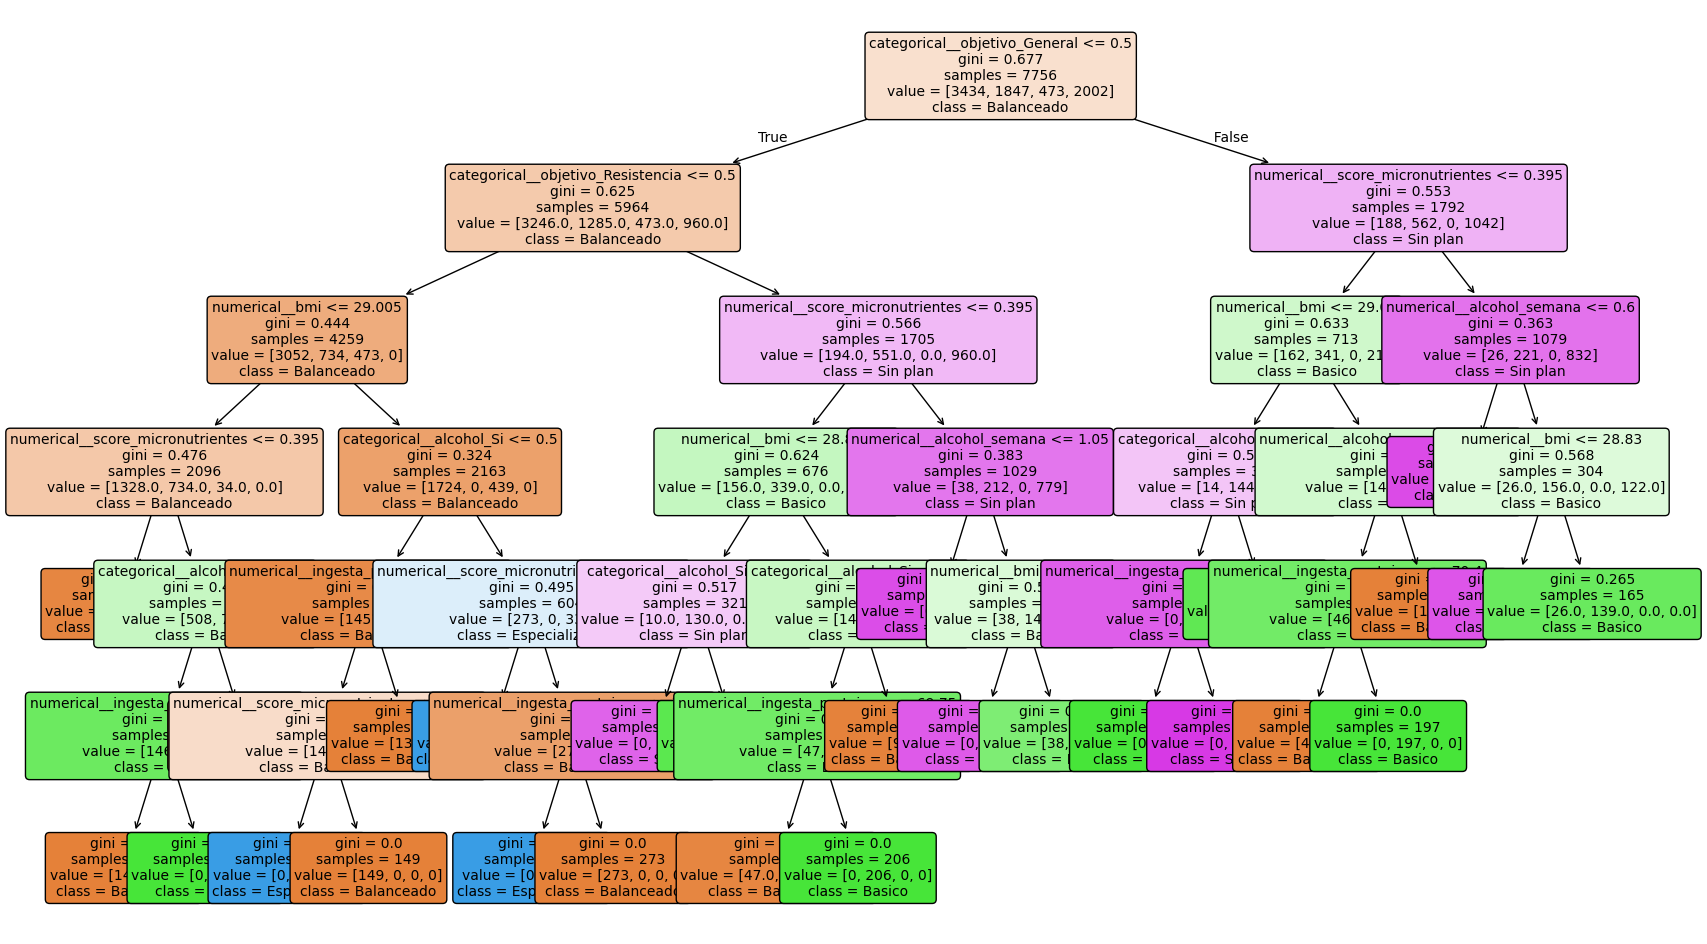

In [306]:
feature_names = best_n_model.named_steps['preprocessor'].get_feature_names_out()
tree = best_n_model.named_steps['model']
plt.figure(figsize=(20, 12))
plot_tree(
    tree,
    feature_names=feature_names,
    class_names=tree.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()

In [303]:
arbol_reglas = export_text(tree, feature_names=list(feature_names))
print(arbol_reglas)

|--- categorical__objetivo_General <= 0.50
|   |--- categorical__objetivo_Resistencia <= 0.50
|   |   |--- numerical__bmi <= 29.01
|   |   |   |--- numerical__score_micronutrientes <= 0.39
|   |   |   |   |--- class: Balanceado
|   |   |   |--- numerical__score_micronutrientes >  0.39
|   |   |   |   |--- categorical__alcohol_Si <= 0.50
|   |   |   |   |   |--- numerical__ingesta_proteinas <= 69.90
|   |   |   |   |   |   |--- class: Balanceado
|   |   |   |   |   |--- numerical__ingesta_proteinas >  69.90
|   |   |   |   |   |   |--- class: Basico
|   |   |   |   |--- categorical__alcohol_Si >  0.50
|   |   |   |   |   |--- class: Balanceado
|   |   |--- numerical__bmi >  29.01
|   |   |   |--- categorical__alcohol_Si <= 0.50
|   |   |   |   |--- numerical__ingesta_proteinas <= 69.95
|   |   |   |   |   |--- numerical__score_micronutrientes <= 0.39
|   |   |   |   |   |   |--- class: Especializado
|   |   |   |   |   |--- numerical__score_micronutrientes >  0.39
|   |   |   |   |   | 

### Árbol Entrenamiento

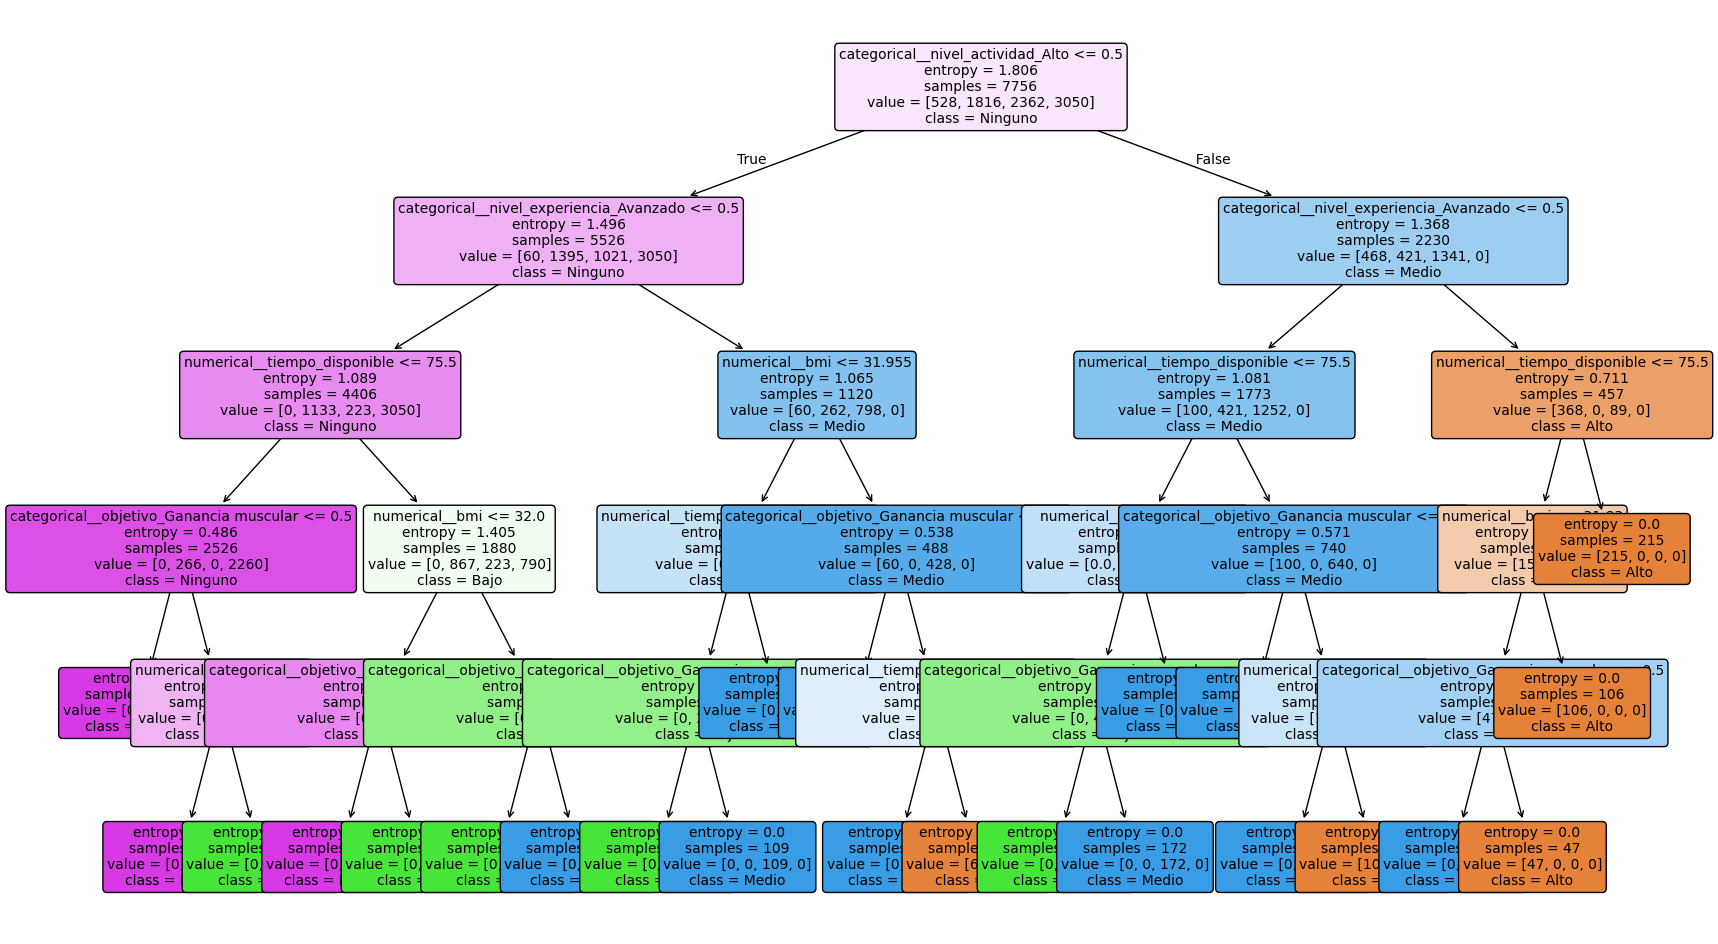

In [307]:
feature_names = best_e_model.named_steps['preprocessor'].get_feature_names_out()
tree2 = best_e_model.named_steps['model']
plt.figure(figsize=(20, 12))
plot_tree(
    tree2,
    feature_names=feature_names,
    class_names=tree2.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()

In [308]:
arbol_reglas = export_text(tree2, feature_names=list(feature_names))
print(arbol_reglas)

|--- categorical__nivel_actividad_Alto <= 0.50
|   |--- categorical__nivel_experiencia_Avanzado <= 0.50
|   |   |--- numerical__tiempo_disponible <= 75.50
|   |   |   |--- categorical__objetivo_Ganancia muscular <= 0.50
|   |   |   |   |--- class: Ninguno
|   |   |   |--- categorical__objetivo_Ganancia muscular >  0.50
|   |   |   |   |--- numerical__bmi <= 32.00
|   |   |   |   |   |--- class: Ninguno
|   |   |   |   |--- numerical__bmi >  32.00
|   |   |   |   |   |--- class: Bajo
|   |   |--- numerical__tiempo_disponible >  75.50
|   |   |   |--- numerical__bmi <= 32.00
|   |   |   |   |--- categorical__objetivo_Ganancia muscular <= 0.50
|   |   |   |   |   |--- class: Ninguno
|   |   |   |   |--- categorical__objetivo_Ganancia muscular >  0.50
|   |   |   |   |   |--- class: Bajo
|   |   |   |--- numerical__bmi >  32.00
|   |   |   |   |--- categorical__objetivo_Ganancia muscular <= 0.50
|   |   |   |   |   |--- class: Bajo
|   |   |   |   |--- categorical__objetivo_Ganancia muscul

## Análisis de resultados

Primero veamos las variables seleccionadas por los modelos:

In [ ]:
best_preprocessor = best_n_model.named_steps['preprocessor']
best_decision_tree = best_n_model.named_steps['model']
feature_names = best_preprocessor.get_feature_names_out()
feature_names = [name.split('__')[-1] for name in feature_names]
importances = best_decision_tree.feature_importances_
feature_importance_df = pd.Series(importances, index=feature_names).sort_values(ascending=False)

feature_importance_df

score_micronutrientes                   0.202172
objetivo_Resistencia                    0.186564
alcohol_Si                              0.178950
ingesta_proteinas                       0.137093
bmi                                     0.118676
objetivo_General                        0.113844
alcohol_semana                          0.062701
tiempo_disponible                       0.000000
cantidad_equipo                         0.000000
horas_sueno                             0.000000
altura                                  0.000000
cigarrillos_dia                         0.000000
pasos_dia                               0.000000
peso                                    0.000000
edad                                    0.000000
objetivo_Ganancia muscular              0.000000
ingesta_agua                            0.000000
condicion_salud_Asma                    0.000000
objetivo_Perdida grasa                  0.000000
condicion_salud_Enfermedad corazon      0.000000
condicion_salud_Hipe

In [269]:
best_preprocessor = best_e_model.named_steps['preprocessor']
best_decision_tree = best_e_model.named_steps['model']
feature_names = best_preprocessor.get_feature_names_out()
feature_names = [name.split('__')[-1] for name in feature_names]
importances = best_decision_tree.feature_importances_
feature_importance_df = pd.Series(importances, index=feature_names).sort_values(ascending=False)

feature_importance_df

objetivo_Ganancia muscular              0.247620
nivel_experiencia_Avanzado              0.220156
bmi                                     0.202008
nivel_actividad_Alto                    0.192394
tiempo_disponible                       0.137822
altura                                  0.000000
peso                                    0.000000
cantidad_equipo                         0.000000
cigarrillos_dia                         0.000000
score_micronutrientes                   0.000000
alcohol_semana                          0.000000
ingesta_proteinas                       0.000000
pasos_dia                               0.000000
horas_sueno                             0.000000
edad                                    0.000000
objetivo_General                        0.000000
ingesta_agua                            0.000000
objetivo_Perdida grasa                  0.000000
objetivo_Resistencia                    0.000000
condicion_salud_Enfermedad corazon      0.000000
condicion_salud_Hipe

## Análisis y discusión

### 1. ¿Qué características del cliente parecen estar más relacionadas con el tipo de plan recomendado?

A partir de las importancias de características extraídas de los modelos de árboles de decisión (atributo `feature_importances_`), se identificaron las variables que el modelo consideró más discriminativas al momento de hacer divisiones.

**Para `plan_entrenamiento`** (modelo `entrenamiento_DT`, criterion=entropy, max_depth=5):

| Variable | Importancia |
|---|---|
| `objetivo_Ganancia muscular` | 0.2476 |
| `nivel_experiencia_Avanzado` | 0.2202 |
| `bmi` | 0.2020 |
| `nivel_actividad_Alto` | 0.1924 |
| `tiempo_disponible` | 0.1378 |

**Para `plan_nutricion`** (modelo `nutricion_DT`, criterion=gini, max_depth=10):

| Variable | Importancia |
|---|---|
| `score_micronutrientes` | 0.2022 |
| `objetivo_Resistencia` | 0.1866 |
| `alcohol_Si` | 0.1790 |
| `ingesta_proteinas` | 0.1371 |
| `bmi` | 0.1187 |
| `objetivo_General` | 0.1138 |
| `alcohol_semana` | 0.0627 |

En términos generales, el objetivo declarado por el cliente (`objetivo`), su nivel de actividad y experiencia, el BMI y el tiempo disponible son los factores más determinantes para el plan de entrenamiento. Para el plan de nutrición, los hábitos de consumo (alcohol, proteínas) y el score de micronutrientes toman el rol protagónico junto al objetivo y el BMI.

---

### 2. ¿Existen variables que podrían ser redundantes o poco informativas?

Sí. Varias variables presentan importancia igual a $0$ en ambos modelos, lo que indica que el árbol nunca las usó para dividir ningún nodo. Esto sugiere que son poco informativas, dado el espacio de características disponible.

**Variables potencialmente redundantes:**

- **`peso` y `altura`**: Ambas están implícitamente capturadas por el $\text{BMI} = \frac{\text{peso}}{\text{altura}^2}$, que sí fue seleccionado por ambos modelos. Mantenerlas puede introducir multicolinealidad conceptual.

- **`fumador` y `cigarrillos_dia`**: La primera es un indicador binario y la segunda es el conteo continuo. Si una persona no fuma, `cigarrillos_dia = 0`, por lo que contienen información redundante.

- **`alcohol` y `alcohol_semana`**: Misma lógica anterior; el valor de unidades por semana es cero para quienes no consumen.

- **`genero`, `edad`, `horas_sueno`, `pasos_dia`, `ingesta_agua`**: Ninguna de estas fue utilizada por ninguno de los dos árboles finales, por lo que no aportaron poder discriminativo en el contexto de este dataset.

- **`dieta_preferida`, `entrenamiento_preferido`, `condicion_salud`**: Tampoco aparecen en los árboles finales con importancia positiva.

Esto no necesariamente implica que sean irrelevantes en un contexto clínico real, sino que en el presente dataset no son predictivas de las etiquetas definidas.

---

### 3. ¿El modelo logra reproducir adecuadamente las recomendaciones presentes en los datos?

Los resultados de la comparación de modelos muestran:

| Modelo | Precision | Recall | F1 | Accuracy | CV Mean | CV Std |
|---|---|---|---|---|---|---|
| `entrenamiento_LR` | 0.8867 | 0.8823 | 0.8842 | 0.8923 | 0.8845 | 0.0108 |
| `nutricion_LR` | 0.8019 | 0.7841 | 0.7924 | 0.8278 | 0.7877 | 0.0216 |
| `entrenamiento_DT` | **1.0000** | **1.0000** | **1.0000** | **1.0000** | **0.9984** | **0.0023** |
| `nutricion_DT` | 0.9613 | 0.9448 | 0.9517 | 0.9567 | 0.9470 | 0.0097 |

El modelo `entrenamiento_DT` alcanza métricas perfectas ($F1 = 1.0$, $\text{Accuracy} = 1.0$) en el conjunto de prueba, con una media de validación cruzada de $0.9984$ y una desviación estándar muy baja ($\sigma = 0.0023$). El modelo `nutricion_DT` también muestra un desempeño muy alto ($\text{Accuracy} \approx 0.957$, $F1 \approx 0.952$).

El $F_1$-macro utilizado como métrica de optimización en el GridSearch es:
$$F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

El $F_1$-macro pondera igual todas las clases, independientemente de su frecuencia.

Un rendimiento tan cercano a $1.0$ —especialmente en `entrenamiento_DT`— sugiere fuertemente que los planes en los datos de entrenamiento fueron asignados mediante reglas determinísticas (posiblemente generadas por lógica de negocio o un árbol de reglas), más que por juicio humano. Los árboles de decisión son capaces de recuperar esas reglas de forma casi exacta. En un escenario con datos reales y etiquetas humanas, este nivel de rendimiento sería atípico.

---

### 4. Reglas del árbol de decisión, explicabilidad, utilidad y limitaciones

#### 4.1 Árbol de plan de entrenamiento (`entrenamiento_DT`)

Este árbol usa 5 variables: `nivel_actividad_Alto`, `nivel_experiencia_Avanzado`, `tiempo_disponible`, `objetivo_Ganancia muscular` y `bmi`. Las clases de salida son: **Ninguno, Bajo, Medio, Alto**.

La lógica completa del árbol puede resumirse en las siguientes reglas consolidadas:

**Bloque A — Actividad NO alta (`nivel_actividad_Alto = 0`) + Experiencia NO avanzada:**

| `tiempo_disponible` | `objetivo_Ganancia muscular` | `bmi` | Plan |
|---|---|---|---|
| ≤ 75.5 | No | — | **Ninguno** |
| ≤ 75.5 | Sí | ≤ 32.0 | **Ninguno** |
| ≤ 75.5 | Sí | > 32.0 | **Bajo** |
| > 75.5 | No | ≤ 32.0 | **Ninguno** |
| > 75.5 | Sí | ≤ 32.0 | **Bajo** |
| > 75.5 | No | > 32.0 | **Bajo** |
| > 75.5 | Sí | > 32.0 | **Medio** |

**Bloque B — Actividad NO alta + Experiencia avanzada:**

| `bmi` | `tiempo_disponible` | `objetivo_Ganancia muscular` | Plan |
|---|---|---|---|
| ≤ 31.95 | ≤ 75.5 | No | **Bajo** |
| ≤ 31.95 | ≤ 75.5 | Sí | **Medio** |
| ≤ 31.95 | > 75.5 | — | **Medio** |
| > 31.95 | — | No | **Medio** |
| > 31.95 | ≤ 75.5 | Sí | **Medio** |
| > 31.95 | > 75.5 | Sí | **Alto** |

**Bloque C — Actividad alta + Experiencia NO avanzada:**

| `tiempo_disponible` | `bmi` | `objetivo_Ganancia muscular` | Plan |
|---|---|---|---|
| ≤ 75.5 | ≤ 31.94 | No | **Bajo** |
| ≤ 75.5 | ≤ 31.94 | Sí | **Medio** |
| ≤ 75.5 | > 31.94 | — | **Medio** |
| > 75.5 | No | — | **Medio** |
| > 75.5 | Sí | ≤ 31.91 | **Medio** |
| > 75.5 | Sí | > 31.91 | **Alto** |

**Bloque D — Actividad alta + Experiencia avanzada:**

| `tiempo_disponible` | `bmi` | `objetivo_Ganancia muscular` | Plan |
|---|---|---|---|
| ≤ 75.5 | ≤ 31.83 | No | **Medio** |
| ≤ 75.5 | ≤ 31.83 | Sí | **Alto** |
| ≤ 75.5 | > 31.83 | — | **Alto** |
| > 75.5 | — | — | **Alto** |

**Patrón general identificado:** la intensidad del plan de entrenamiento escala progresivamente con el nivel de actividad, la experiencia, el tiempo disponible y el objetivo de ganancia muscular. El $\text{BMI}$ actúa como un factor agravante que puede elevar el plan una categoría cuando supera el umbral $\approx 32$.

---

#### 4.2 Árbol de plan de nutrición (`nutricion_DT`)

Este árbol usa 6 variables: `objetivo_General`, `objetivo_Resistencia`, `bmi`, `score_micronutrientes`, `alcohol_Si`, `ingesta_proteinas` y `alcohol_semana`. Las clases son: **Sin plan, Básico, Balanceado, Especializado**.

**Bloque I — objetivo ≠ General y objetivo ≠ Resistencia (ej. Ganancia muscular, Pérdida grasa):**

| `bmi` | `score_micronutrientes` | `alcohol_Si` | `ingesta_proteinas` | Plan |
|---|---|---|---|---|
| ≤ 29.01 | ≤ 0.39 | — | — | **Balanceado** |
| ≤ 29.01 | > 0.39 | No | ≤ 69.90 | **Balanceado** |
| ≤ 29.01 | > 0.39 | No | > 69.90 | **Básico** |
| ≤ 29.01 | > 0.39 | Sí | — | **Balanceado** |
| > 29.01 | — | No | ≤ 69.95 | ≤ 0.39 → **Especializado** |
| > 29.01 | — | No | ≤ 69.95 | > 0.39 → **Balanceado** |
| > 29.01 | — | No | > 69.95 | — | **Balanceado** |
| > 29.01 | ≤ 0.39 | Sí | — | **Especializado** |
| > 29.01 | > 0.39 | Sí | ≤ 70.35 | **Especializado** |
| > 29.01 | > 0.39 | Sí | > 70.35 | **Balanceado** |

**Bloque II — objetivo = Resistencia:**

| `score_micronutrientes` | `bmi` | `alcohol_Si` | `ingesta_proteinas` / `alcohol_semana` | Plan |
|---|---|---|---|---|
| ≤ 0.39 | ≤ 28.89 | No | — | **Sin plan** |
| ≤ 0.39 | ≤ 28.89 | Sí | — | **Básico** |
| ≤ 0.39 | > 28.89 | No | ≤ 69.75 | **Balanceado** |
| ≤ 0.39 | > 28.89 | No | > 69.75 | **Básico** |
| ≤ 0.39 | > 28.89 | Sí | — | **Balanceado** |
| > 0.39 | — | — | `alcohol_semana` ≤ 1.05 | **Sin plan** |
| > 0.39 | ≤ 28.99 | — | `alcohol_semana` > 1.05 | **Sin plan** |
| > 0.39 | > 28.99 | — | `alcohol_semana` > 1.05 | **Básico** |

**Bloque III — objetivo = General:**

| `score_micronutrientes` | `bmi` | `alcohol_Si` / `alcohol_semana` | `ingesta_proteinas` | Plan |
|---|---|---|---|---|
| ≤ 0.39 | ≤ 29.05 | No | ≤ 69.85 | **Básico** |
| ≤ 0.39 | ≤ 29.05 | No | > 69.85 | **Sin plan** |
| ≤ 0.39 | ≤ 29.05 | Sí | — | **Básico** |
| ≤ 0.39 | > 29.05 | `alcohol_semana` ≤ 0.85 | ≤ 70.40 | **Balanceado** |
| ≤ 0.39 | > 29.05 | `alcohol_semana` ≤ 0.85 | > 70.40 | **Básico** |
| ≤ 0.39 | > 29.05 | `alcohol_semana` > 0.85 | — | **Balanceado** |
| > 0.39 | — | `alcohol_semana` ≤ 0.60 | — | **Sin plan** |
| > 0.39 | ≤ 28.83 | `alcohol_semana` > 0.60 | — | **Sin plan** |
| > 0.39 | > 28.83 | `alcohol_semana` > 0.60 | — | **Básico** |

**Patrón general identificado:** el plan de nutrición más intensivo (*Especializado*) aparece cuando hay alto $\text{BMI}$, consumo de alcohol y bajo score de micronutrientes, principalmente en objetivos que no son Resistencia ni General. El plan *Sin plan* se asigna a perfiles con buen score de micronutrientes y objetivo de Resistencia o General, sugiriendo que quien ya tiene buena nutrición y objetivos moderados no requiere intervención nutricional activa.

---

#### 4.3 Utilidad de las reglas IF-THEN en árboles de decisión

La calidad de cada división en el árbol se mide mediante la reducción de impureza. Las reglas resultantes son útiles por varias razones:

- **Explicabilidad local directa**: para cualquier cliente, es posible seguir la ruta exacta nodo a nodo y enunciar en lenguaje natural por qué recibió ese plan. Por ejemplo: *"Su plan es **Alto** porque tiene nivel de actividad alto, experiencia avanzada y tiempo disponible superior a 75.5 minutos"*.
- **Auditabilidad**: un entrenador o médico puede revisar si la lógica del árbol es clínicamente razonable sin necesidad de conocer álgebra lineal ni redes neuronales.
- **Independencia de escala**: las reglas operan directamente sobre los valores originales (o codificados) de las variables sin requerir normalización para ser interpretadas.

---

#### 4.4 Limitaciones de las reglas en árboles de decisión

- **Fronteras de decisión en escalera**: los árboles solo producen particiones ortogonales (paralelas a los ejes). Relaciones diagonales o curvilíneas entre variables no se capturan eficientemente; se necesitan muchas divisiones para aproximarlas.

- **Explosión del número de reglas con la profundidad**: con `max_depth=10` y `max_leaf_nodes=27`, el árbol de nutrición ya genera decenas de reglas. En árboles más profundos la explicabilidad global se degrada, aunque cada hoja siga siendo individualmente interpretable.

- **Umbrales aparentemente arbitrarios**: valores como $\text{BMI} \leq 29.01$ o $\text{ingesta\_proteinas} \leq 69.90$ son umbrales exactos aprendidos de los datos de entrenamiento. Pequeñas variaciones alrededor de ese punto (e.g., $\text{BMI} = 29.00$ vs $29.02$) producen predicciones distintas, lo que puede resultar contraintuitivo para usuarios y profesionales.

- **Interacciones de orden superior ignoradas**: el árbol captura interacciones en secuencia (condicional en la ruta), pero no modela interacciones entre variables que están en ramas distintas del árbol para una misma hoja.

### 5. ¿Cómo podría integrarse este tipo de modelo en una plataforma digital de fitness o bienestar?

Una integración viable en una plataforma de fitness implicaría los siguientes componentes:

1. **Formulario de perfil inicial**: Al registrarse, el usuario completa sus datos: objetivo, nivel de actividad, nivel de experiencia, condición de salud, dieta preferida, hábitos de consumo y métricas físicas (peso, altura para calcular $\text{BMI}$). Esto alimenta el vector de características $\mathbf{x}$ que el modelo recibe.

2. **API de inferencia**: El modelo serializado (por ejemplo con `joblib` o `pickle`) se expone como un servicio REST. Al completar el perfil, la app realiza una llamada que devuelve `plan_entrenamiento` y `plan_nutricion`.

3. **Capa de reglas de negocio y seguridad**: Dado que el modelo puede sugerir planes de alta intensidad a personas con condiciones médicas, se aplica una capa de validación posterior. Por ejemplo: si `condicion_salud = Enfermedad_corazon` y el modelo recomienda un plan de alta intensidad, la plataforma puede escalar la recomendación a supervisión médica.

4. **Re-entrenamiento continuo**: Se puede implementar un ciclo de retroalimentación donde los usuarios califican la pertinencia del plan y los entrenadores aprueban o corrigen recomendaciones. Estos nuevos datos etiquetados permiten re-entrenar periódicamente el modelo ($\text{online learning}$ o re-entrenamientos por lotes).

5. **Panel de explicabilidad**: La ruta de decisión del árbol se visualiza como una serie de condiciones legibles: "Tu plan es *Alto* porque tu objetivo es *Ganancia muscular*, tienes nivel de actividad *Alto* y experiencia *Avanzada*."

---

### 6. ¿Qué limitaciones tendría utilizar un sistema automático para recomendar planes de entrenamiento?

- **Falta de contexto clínico profundo**: El modelo opera sobre variables discretas y agregadas. No captura señales dinámicas como frecuencia cardíaca en reposo, VO₂ máximo, historial de lesiones detallado o variabilidad del ritmo circadiano, que son relevantes para un entrenador personal.

- **Rigidez ante cambios de estado**: Una vez asignado el plan, el modelo no se adapta automáticamente a la progresión del usuario (mejora del fitness, lesiones nuevas, cambios de objetivo). Requiere que el usuario actualice su perfil y vuelva a ejecutar la predicción.

- **Homogeneización de recomendaciones**: Si el modelo tiene poca diversidad en los planes disponibles (clases de salida), puede asignar el mismo plan a perfiles muy distintos que coinciden en las variables clave, perdiendo personalización real.

- **Dependencia de auto-reporte**: Variables como `horas_sueno`, `ingesta_proteinas` o `pasos_dia` dependen de que el usuario las reporte con precisión, lo que introduce ruido considerable en la predicción.

- **Ausencia de retroalimentación fisiológica en tiempo real**: El modelo no puede ajustar la recomendación con base en cómo responde el cuerpo del usuario durante el entrenamiento.

- **Responsabilidad legal y médica**: En caso de lesión o consecuencia adversa derivada de una recomendación incorrecta, la responsabilidad del sistema automatizado no está bien definida. Esto limita su uso en contextos clínicos sin supervisión profesional.

---

### 7. ¿Qué fuentes de sesgo podrían estar presentes en los datos o en el proceso de modelado?

**Sesgos en los datos:**

- **Sesgo de selección**: Si los datos provienen de usuarios activos de una plataforma de fitness, los perfiles sedentarios o con condiciones de salud complejas están subrepresentados, haciendo que el modelo sea menos confiable para esos grupos.

- **Sesgo de auto-reporte**: Variables como `ingesta_proteinas`, `horas_sueno`, `pasos_dia` e `ingesta_agua` suelen ser sobreestimadas o subestimadas por los usuarios según expectativas sociales (efecto de deseabilidad social).

- **Sesgo de datos generados sintéticamente**: Los resultados casi perfectos del modelo `entrenamiento_DT` ($F_1 = 1.0$) sugieren que los planes fueron asignados por reglas determinísticas, no por juicio humano real. En ese caso, el modelo simplemente aprende esas reglas, lo que introduce un sesgo de confirmación: si las reglas originales eran incorrectas o incompletas, el modelo las reproducirá fielmente.

- **Desbalance de clases**: Si ciertas categorías de plan (e.g., "Ninguno" o "Sin plan") son mucho más frecuentes, un modelo optimizado por $F_1$-macro puede aún subclasificar clases minoritarias pese a métricas globales altas.

**Sesgos en el proceso de modelado:**

- **Sesgo de selección de variables**: Al excluir variables como `genero`, `edad` o `condicion_salud` (que el árbol ignoró), el modelo puede ser incapaz de distinguir casos donde esas variables son médicamente relevantes.

- **Sesgo de hiperparámetros**: El `GridSearchCV` con `f1_macro` como criterio de optimización favorece modelos que equilibran clases, pero no necesariamente los más seguros para perfiles de riesgo clínico.

- **Sesgo de variable proxy**: El `BMI` es una variable derivada que, como medida de adiposidad, tiene sesgos conocidos (no distingue entre masa muscular y grasa, y su interpretación varía según etnia y sexo). Usar `BMI` como variable principal puede perpetuar recomendaciones inadecuadas para grupos con morfología atípica.

# Predicción en el conjunto de test

In [292]:
# Leer el dataset de prueba
test_df = pd.read_csv(TEST_FILE, sep=";", encoding='iso-8859-1')
test_df.head()

,Edad,Gnereo,Peso,Altura,BMI,Objetivo,Condicion_salud,Nivel_Actividad,Nivel_experiencia,Dieta_preferida,...,Fumador,Cigarrillos_dia,Alcohol,Alcohol_semana,Score_micronutrientes,Ingesta_proteinas,Pasos_dia,Ingesta_agua,Plan_entrenamiento,Plan_nutrición
0,32,Femenino,77.3,1.54,32.59,Ganancia muscular,Lesion,Bajo,Intermedio,Vegetariano,...,0,0.0,0,0.0,0.21,169.0,8468,2.57,NaN,NaN
1,29,Masculino,79.6,1.82,24.03,General,Ninguno,Alto,Avanzado,Vegetariano,...,0,0.0,0,0.0,0.58,52.4,11967,3.73,NaN,NaN
2,33,Femenino,107.2,1.57,43.49,General,Hipertension,Alto,Principiante,Vegano,...,0,0.0,0,0.0,0.37,189.5,15950,3.06,NaN,NaN
3,42,Femenino,103.5,1.67,37.11,General,Asma,Bajo,Principiante,No-Vegetariano,...,0,0.0,0,0.0,0.57,185.7,9384,2.18,NaN,NaN
4,29,Masculino,76.0,2.02,18.63,Ganancia muscular,Ninguno,Bajo,Intermedio,Pescetariano,...,0,0.0,1,23.7,0.21,182.1,10070,3.32,NaN,NaN


In [299]:
test_df_clean = test_df.drop(columns=["Plan_entrenamiento", "Plan_nutrición"])
y_pred_e = best_e_model.predict(test_df_clean)
y_pred_n = best_n_model.predict(test_df_clean)

# 1) Predicción como Serie con el mismo índice
y_pred_e_series = pd.Series(y_pred_e, index=test_df.index, name="Plan_entrenamiento")
y_pred_n_series = pd.Series(y_pred_n, index=test_df.index, name="Plan_nutrición")

# 2) Concatenar alineando por índice
df_out = pd.concat([test_df_clean, y_pred_e_series, y_pred_n_series], axis=1)

# 3) Guardar
df_out.to_csv("data/predictions.csv", index=True)

### Uso de la IA generativa

- Todo lo relacionado con estética visual fue hecho con ChatGPT. Básicamente le pasábamos nuestro código y le decíamos “hazlo mas bonito”. Las tablas de comparación con tonos de azul, por ejemplo, fueron hechas así. 
- Gran parte del código lo copiamos y pegamos de los Laboratorios, **la IA no nos ayudó a desarrollar los modelos como tal**, pero si a hacer debugging, ya que tuvimos muchos errores durante el entrenamiento.
- Las funciones de limpieza de datos si las hizo ChatGPT, básicamente le pedíamos “haz una función que haga esto…”. También las gráficas del principio le pedimos a ChatGPT que nos las hiciera.
